# 🔍 Fraud Detection — Exploratory Data Analysis
Dataset: Credit Card Fraud Detection (ULB / Kaggle)
284,807 transactions | 492 frauds (0.172%)

In [8]:
import os

# Paths
if os.path.exists('/content/creditcard.csv'):
    DATA_PATH = '/content/creditcard.csv'
    REPORTS_DIR = '/content/reports'      # Colab
    MODELS_DIR = '/content/models'
else:
    DATA_PATH = '../data/creditcard.csv'
    REPORTS_DIR = '../reports'            # Local
    MODELS_DIR = '../models'

# Create folders if they don't exist
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print('Paths set!')
print(f'Data   : {DATA_PATH}')
print(f'Reports: {REPORTS_DIR}')
print(f'Models : {MODELS_DIR}')

Paths set!
Data   : /content/creditcard.csv
Reports: /content/reports
Models : /content/models


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
sns.set_palette('husl')

df = pd.read_csv('/content/creditcard.csv')
print('Shape:', df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Basic Info

In [10]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum().sum(), 'total missing values')
print('\n=== Basic Stats ===')
df[['Amount', 'Time', 'Class']].describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

,Amount,Time,Class
count,284807.000000,284807.000000,284807.000000
mean,88.349619,94813.859575,0.001727
std,250.120109,47488.145955,0.041527
min,0.000000,0.000000,0.000000
25%,5.600000,54201.500000,0.000000
50%,22.000000,84692.000000,0.000000
75%,77.165000,139320.500000,0.000000
max,25691.160000,172792.000000,1.000000


## 2. Class Imbalance — The Core Problem

Legitimate transactions : 284,315 (99.83%)
Fraudulent transactions : 492 (0.1727%)


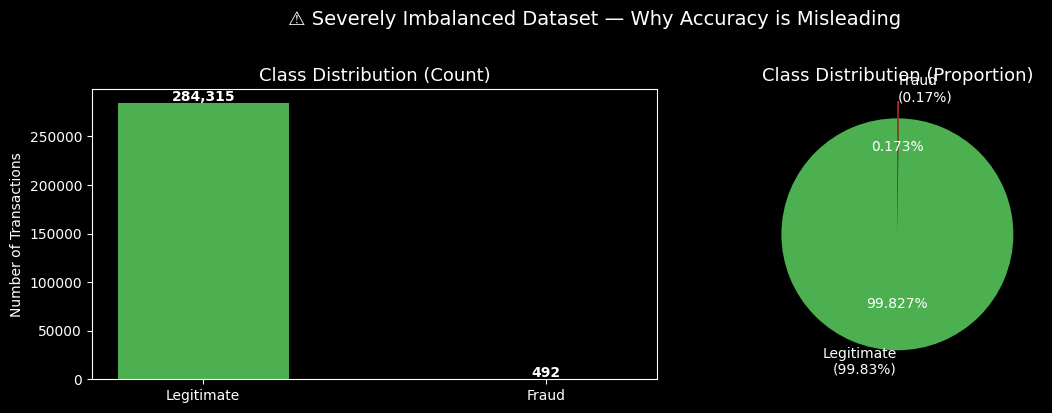

In [11]:
class_counts = df['Class'].value_counts()
fraud_pct = class_counts[1] / len(df) * 100

print(f'Legitimate transactions : {class_counts[0]:,} ({100 - fraud_pct:.2f}%)')
print(f'Fraudulent transactions : {class_counts[1]:,} ({fraud_pct:.4f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#4CAF50', '#F44336']
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values, color=colors, width=0.5)
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=['Legitimate\n(99.83%)', 'Fraud\n(0.17%)'],
    colors=colors,
    autopct='%1.3f%%',
    startangle=90,
    explode=(0, 0.15)
)
axes[1].set_title('Class Distribution (Proportion)', fontsize=13)

plt.suptitle('⚠️ Severely Imbalanced Dataset — Why Accuracy is Misleading', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Transaction Amount Distribution

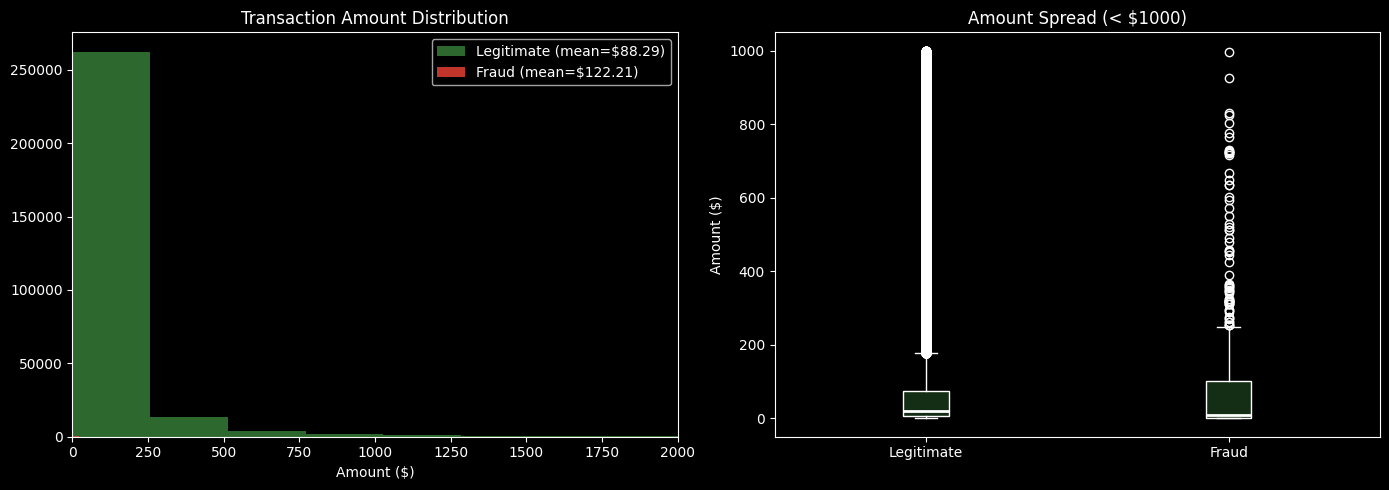

Legitimate — Mean: $88.29, Max: $25691.16
Fraud      — Mean: $122.21, Max: $2125.87


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

legit = df[df['Class'] == 0]['Amount']
fraud = df[df['Class'] == 1]['Amount']

# Distribution comparison
axes[0].hist(legit, bins=100, alpha=0.6, color='#4CAF50', label=f'Legitimate (mean=${legit.mean():.2f})')
axes[0].hist(fraud, bins=100, alpha=0.8, color='#F44336', label=f'Fraud (mean=${fraud.mean():.2f})')
axes[0].set_xlim(0, 2000)
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount ($)')
axes[0].legend()

# Box plot
df_plot = df[df['Amount'] < 1000]
axes[1].boxplot(
    [df_plot[df_plot['Class']==0]['Amount'], df_plot[df_plot['Class']==1]['Amount']],
    labels=['Legitimate', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor='#4CAF5044'),
    medianprops=dict(color='white', linewidth=2)
)
axes[1].set_title('Amount Spread (< $1000)')
axes[1].set_ylabel('Amount ($)')

plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Legitimate — Mean: ${legit.mean():.2f}, Max: ${legit.max():.2f}')
print(f'Fraud      — Mean: ${fraud.mean():.2f}, Max: ${fraud.max():.2f}')

## 4. Time Analysis — When Do Frauds Happen?

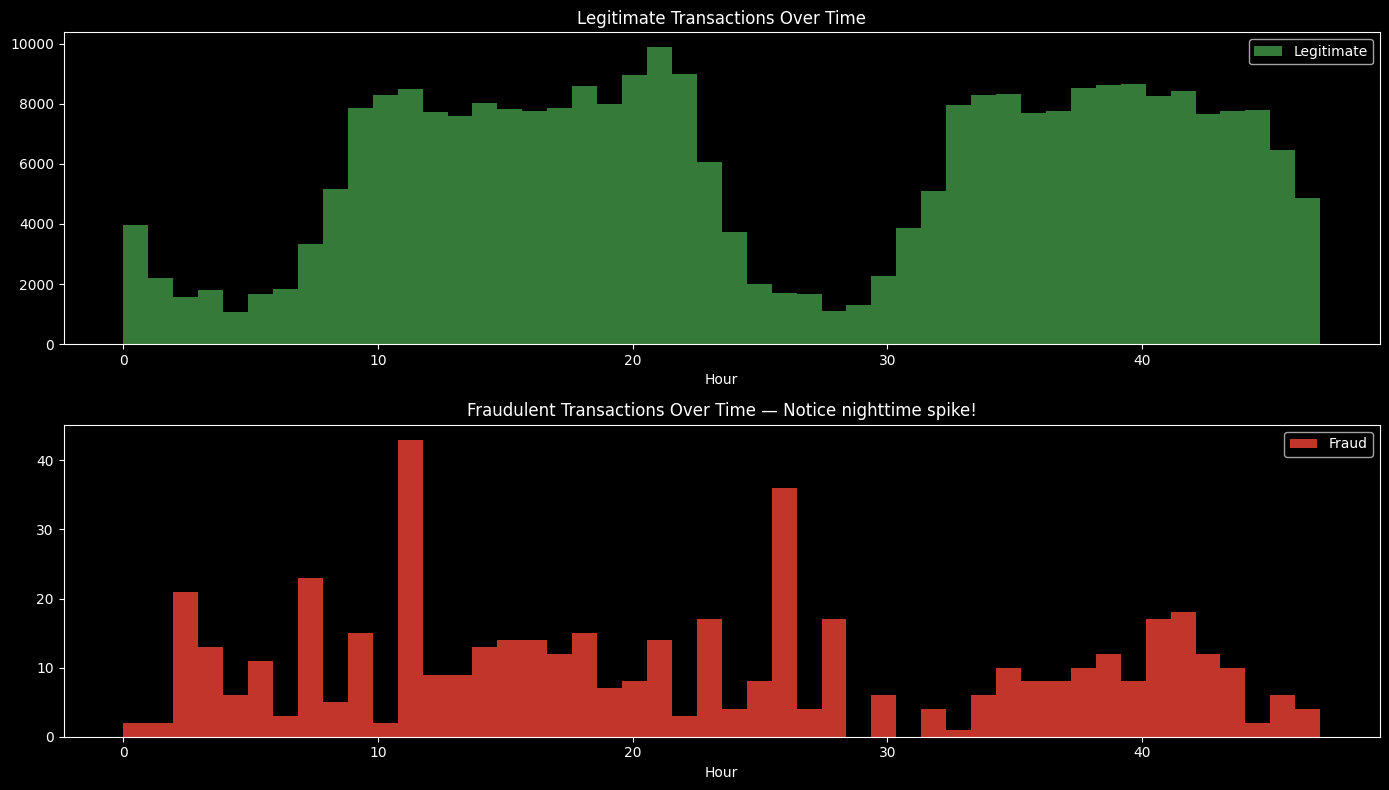

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Convert seconds to hours
df['Hour'] = (df['Time'] / 3600).astype(int) % 48

legit_time = df[df['Class'] == 0]['Hour']
fraud_time = df[df['Class'] == 1]['Hour']

axes[0].hist(legit_time, bins=48, color='#4CAF50', alpha=0.7, label='Legitimate')
axes[0].set_title('Legitimate Transactions Over Time')
axes[0].set_xlabel('Hour')
axes[0].legend()

axes[1].hist(fraud_time, bins=48, color='#F44336', alpha=0.8, label='Fraud')
axes[1].set_title('Fraudulent Transactions Over Time — Notice nighttime spike!')
axes[1].set_xlabel('Hour')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap (PCA Features)

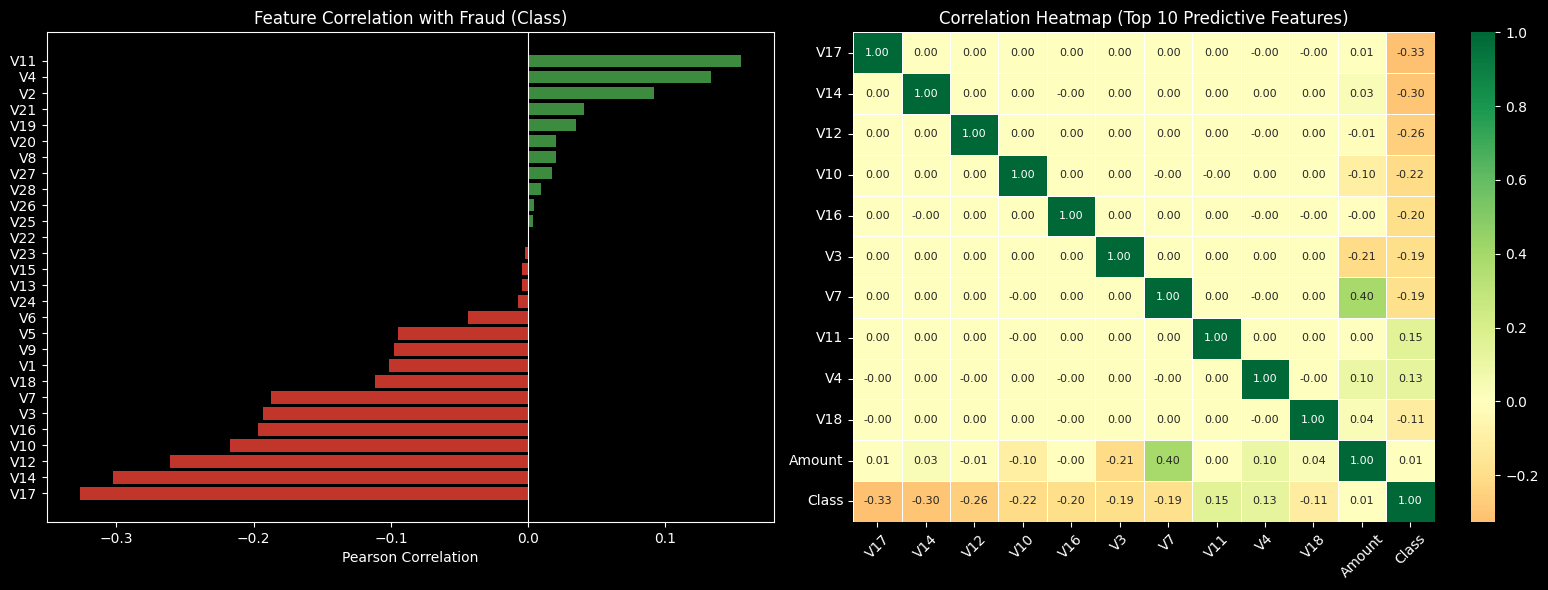

Top 5 features correlated with Fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
Name: Class, dtype: float64


In [15]:
# Correlation with Class — which V features are most predictive?
v_features = [f'V{i}' for i in range(1, 29)]
correlations = df[v_features + ['Class']].corr()['Class'].drop('Class').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: correlation with Class
colors = ['#F44336' if x < 0 else '#4CAF50' for x in correlations]
axes[0].barh(correlations.index, correlations.values, color=colors, alpha=0.8)
axes[0].axvline(0, color='white', linewidth=0.8)
axes[0].set_title('Feature Correlation with Fraud (Class)', fontsize=12)
axes[0].set_xlabel('Pearson Correlation')

# Heatmap of top 10 most correlated features
top_features = correlations.abs().nlargest(10).index.tolist() + ['Amount', 'Class']
corr_matrix = df[top_features].corr()
sns.heatmap(
    corr_matrix,
    ax=axes[1],
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
axes[1].set_title('Correlation Heatmap (Top 10 Predictive Features)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features correlated with Fraud:')
print(correlations.abs().nlargest(5))

## 6. Feature Distributions: Fraud vs Legitimate

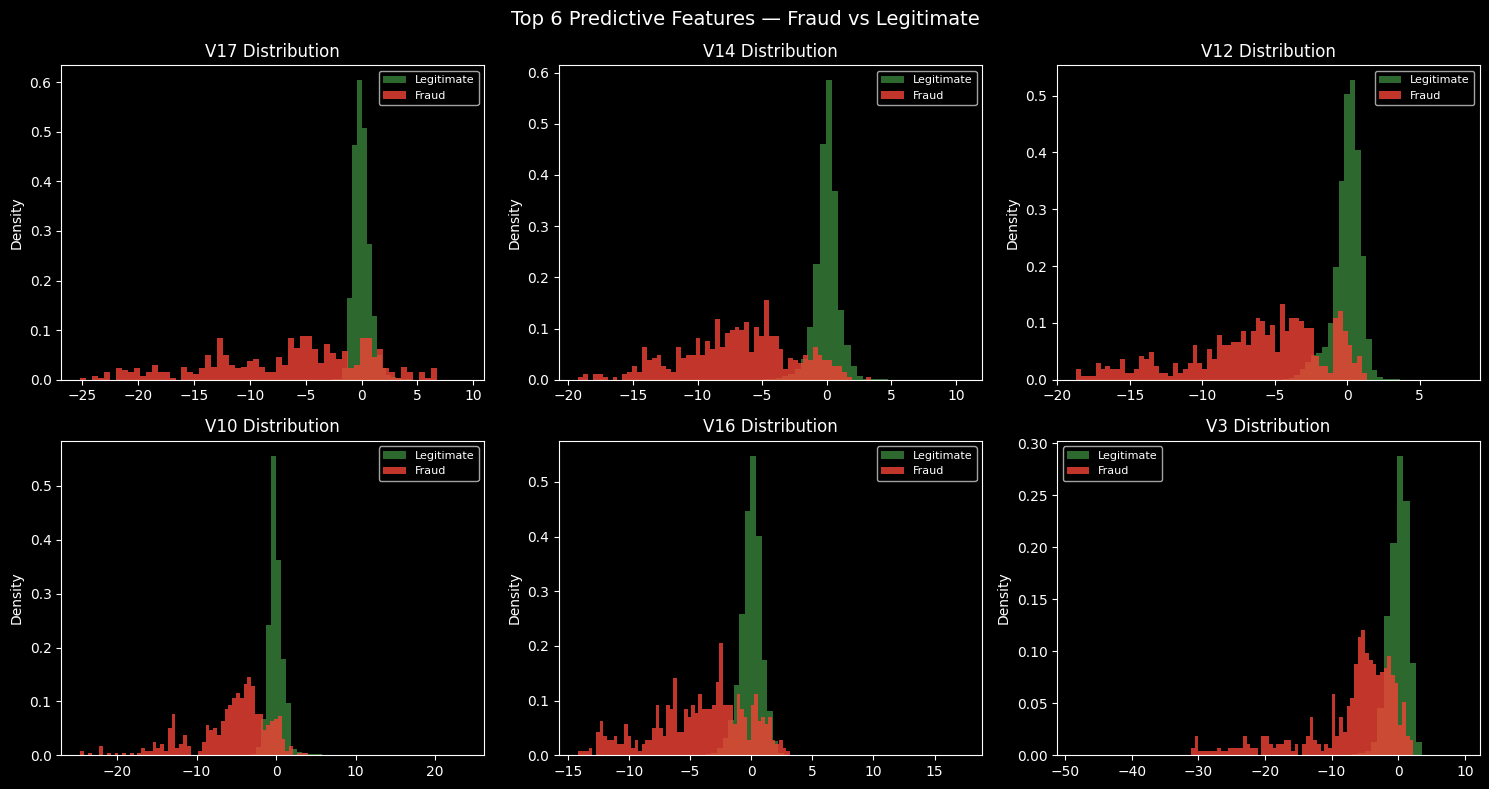

In [16]:
# Top 6 most correlated V features
top6 = correlations.abs().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(top6):
    axes[i].hist(df[df['Class']==0][feature], bins=60, alpha=0.6,
                 color='#4CAF50', label='Legitimate', density=True)
    axes[i].hist(df[df['Class']==1][feature], bins=60, alpha=0.8,
                 color='#F44336', label='Fraud', density=True)
    axes[i].set_title(f'{feature} Distribution')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

plt.suptitle('Top 6 Predictive Features — Fraud vs Legitimate', fontsize=14)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. EDA Summary
| Insight | Finding |
|---|---|
| Class imbalance | 0.172% fraud — severe imbalance, SMOTE needed |
| Fraud amounts | Fraudulent transactions tend to be smaller amounts |
| Time pattern | Fraud spikes during nighttime hours (low-activity period) |
| Top features | V14, V12, V10, V11, V17 most correlated with fraud |
| Missing values | None — clean dataset |